# IMPORTS

In [1]:
import os
import time
import torch
from tqdm import tqdm
from torch.autograd import Variable
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
import torchvision
from torchvision import transforms
from PIL import Image, ImageOps, ImageDraw, ImageFont
from collections import OrderedDict, defaultdict 
from datasets import load_dataset, Dataset
import itertools, datasets
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import torch
from torch.autograd import Variable
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torchvision import transforms
from torchvision.transforms.functional import to_pil_image
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
from pathlib import Path
import nest_asyncio; nest_asyncio.apply()

/home/antonello03/anaconda3/envs/py31/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Model Def

In [2]:
#vgg definition that conveniently let's you grab the outputs from any layer
class VGG(nn.Module):
    def __init__(self, pool='avg'):
        super(VGG, self).__init__()
        #vgg modules
        self.conv1_1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv1_2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv2_1 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv2_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.conv3_1 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv3_2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.conv3_3 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.conv3_4 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.conv4_1 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.conv4_2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv4_3 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv4_4 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv5_1 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv5_2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv5_3 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv5_4 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        if pool == 'max':
            self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
            self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
            self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
            self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
            self.pool5 = nn.MaxPool2d(kernel_size=2, stride=2)
        elif pool == 'avg':
            self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)
            self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
            self.pool3 = nn.AvgPool2d(kernel_size=2, stride=2)
            self.pool4 = nn.AvgPool2d(kernel_size=2, stride=2)
            self.pool5 = nn.AvgPool2d(kernel_size=2, stride=2)

    def forward(self, x, out_keys):
        out = {}
        out['r11'] = F.relu(self.conv1_1(x))
        out['r12'] = F.relu(self.conv1_2(out['r11']))
        out['p1'] = self.pool1(out['r12'])
        out['r21'] = F.relu(self.conv2_1(out['p1']))
        out['r22'] = F.relu(self.conv2_2(out['r21']))
        out['p2'] = self.pool2(out['r22'])
        out['r31'] = F.relu(self.conv3_1(out['p2']))
        out['r32'] = F.relu(self.conv3_2(out['r31']))
        out['r33'] = F.relu(self.conv3_3(out['r32']))
        out['r34'] = F.relu(self.conv3_4(out['r33']))
        out['p3'] = self.pool3(out['r34'])
        out['r41'] = F.relu(self.conv4_1(out['p3']))
        out['r42'] = F.relu(self.conv4_2(out['r41']))
        out['r43'] = F.relu(self.conv4_3(out['r42']))
        out['r44'] = F.relu(self.conv4_4(out['r43']))
        out['p4'] = self.pool4(out['r44'])
        out['r51'] = F.relu(self.conv5_1(out['p4']))
        out['r52'] = F.relu(self.conv5_2(out['r51']))
        out['r53'] = F.relu(self.conv5_3(out['r52']))
        out['r54'] = F.relu(self.conv5_4(out['r53']))
        out['p5'] = self.pool5(out['r54'])
        return [out[key] for key in out_keys]

# gram matrix and loss
class GramMatrix(nn.Module):
    def forward(self, input):
        b,c,h,w = input.size()
        F = input.view(b, c, h*w)
        G = torch.bmm(F, F.transpose(1,2))
        G.div_(h*w)
        return G

class GramMSELoss(nn.Module):
    def forward(self, input, target):
        out = nn.MSELoss()(GramMatrix()(input), target)
        return(out)
    
# pearson correlation loss
class PearsonCorrelationLoss(nn.Module):
    def forward(self, x, y):
        """
        Pearson correlation loss.
        """
        
        x_gram = GramMatrix()(x)

        x_flat = x_gram.view(-1).float()
        y_flat = y.view(-1).float()

        mean_x = torch.mean(x_flat)
        mean_y = torch.mean(y_flat)

        xm = x_flat - mean_x
        ym = y_flat - mean_y

        numer = torch.dot(xm, ym)
        denom = torch.sqrt(torch.dot(xm, xm) * torch.dot(ym, ym))
        eps = 1e-8
        r = numer / (denom + eps)
        distance = 1.0 - r
        return (distance)

# Cosine similarity loss
class CosineSimilarityLoss(nn.Module):
    def forward(self, x, y):
        """
        Cosine similarity loss.
        """
        x_gram = GramMatrix()(x)

        x_flat = x_gram.view(-1).float()
        y_flat = y.view(-1).float()
        # Dot‐product
        dot_xy = torch.dot(x_flat, y_flat)
        # Norme L2
        norm_x = torch.norm(x_flat, p=2)
        norm_y = torch.norm(y_flat, p=2)
        eps = 1e-8
        cos_sim = dot_xy / (norm_x * norm_y + eps)
        return (1.0 - cos_sim)

# pre and post processing for images
img_size = 512
prep = transforms.Compose([transforms.Resize(img_size),
                           transforms.ToTensor(),
                           transforms.Lambda(lambda x: x[torch.LongTensor([2,1,0])]), #turn to BGR
                           transforms.Normalize(mean=[0.40760392, 0.45795686, 0.48501961], #subtract imagenet mean
                                                std=[1,1,1]),
                           transforms.Lambda(lambda x: x.mul_(255)),
                          ])
postpa = transforms.Compose([transforms.Lambda(lambda x: x.mul_(1./255)),
                           transforms.Normalize(mean=[-0.40760392, -0.45795686, -0.48501961], #add imagenet mean
                                                std=[1,1,1]),
                           transforms.Lambda(lambda x: x[torch.LongTensor([2,1,0])]), #turn to RGB
                           ])
postpb = transforms.Compose([transforms.ToPILImage()])
def postp(tensor): # to clip results in the range [0,1]
    t = postpa(tensor)
    t[t>1] = 1
    t[t<0] = 0
    img = postpb(t)
    return img

In [3]:
!rclone mount gdrive: ~/gdrive \
  --vfs-cache-mode writes \
  --drive-pacer-min-sleep 500ms \
  --drive-pacer-burst 5 \
  --tpslimit 4 \
  --tpslimit-burst 4 \
  --checkers 4 \
  --transfers 2 \
  --daemon

In [4]:
model_dir  = "/home/antonello03/gdrive/Colab Notebooks/UNI/ProjectWork/"

vgg = VGG()
vgg.load_state_dict(torch.load(model_dir + 'vgg_conv.pth'))

for param in vgg.parameters():
    param.requires_grad = False
if torch.cuda.is_available():
    vgg.cuda()

# Download Images

In [5]:
stream_ds = load_dataset(
    "huggan/wikiart",
    split="train",        # the dataset has a single split called “train”
    streaming=True        # key flag – nothing is cached locally until you touch it
)

stream_ds

IterableDataset({
    features: ['image', 'artist', 'genre', 'style'],
    num_shards: 72
})

In [6]:
num_threads = num_threads = min(32, (os.cpu_count() or 1) + 4)
stream_ds = stream_ds.decode(num_threads=num_threads)
it = iter(stream_ds)

In [7]:
image_path = "/mnt/e/synthesized-wikiart"

In [8]:
def synthesizeImage(style_image, content_image, loss_fn, style_weights, content_weights, max_iter=500, show_iter=100):
    opt_img = Variable(content_image.data.clone(), requires_grad=True)
    style_layers = ['r11','r21','r31','r41', 'r51']
    content_layers = ['r42']
    loss_layers = style_layers + content_layers
    loss_fns = [loss_fn()] * len(style_layers) + [nn.MSELoss()] * len(content_layers)
    if torch.cuda.is_available():
        loss_fns = [loss_fn.cuda() for loss_fn in loss_fns]

    weights = style_weights + content_weights

    #compute optimization targets
    style_targets = [GramMatrix()(A).detach() for A in vgg(style_image, style_layers)]
    content_targets = [A.detach() for A in vgg(content_image, content_layers)]
    targets = style_targets + content_targets

    #run style transfer
    optimizer = optim.LBFGS([opt_img])
    n_iter=[0]

    while n_iter[0] <= max_iter:

        def closure():
            optimizer.zero_grad()
            out = vgg(opt_img, loss_layers)
            layer_losses = [weights[a] * loss_fns[a](A, targets[a]) for a,A in enumerate(out)]
            loss = torch.sum(torch.stack(layer_losses))
            loss.backward()
            n_iter[0]+=1
            if n_iter[0]%show_iter == (show_iter-1):
                print(f"Iteration {n_iter[0]+1}, loss: {loss.item()}")
                #print([f"{loss_layers[li]}: {l.item()}" for li, l in enumerate(layer_losses)])
            return loss

        optimizer.step(closure)

    return postp(opt_img.data[0].cpu().squeeze())

In [9]:
img_size = 512
prep = transforms.Compose([transforms.Resize(img_size),
                           transforms.ToTensor(),
                           transforms.Lambda(lambda x: x[torch.LongTensor([2,1,0])]), #turn to BGR
                           transforms.Normalize(mean=[0.40760392, 0.45795686, 0.48501961], #subtract imagenet mean
                                                std=[1,1,1]),
                           transforms.Lambda(lambda x: x.mul_(255)),
                          ])

content_img = Image.open("Tuebingens.jpg")
content_img = Variable(prep(content_img).unsqueeze(0).cuda())

In [10]:
rmse_style_weights = [1e3/n**2 for n in [64,128,256,512,512]]
rmse_content_weights = [1e0]
prs_style_weights = [5e7/n**2 for n in [64,128,256,512,512]]
prs_content_weights = [1e-3]
cos_style_weights = [5e7/n**2 for n in [64,128,256,512,512]]
cos_content_weights = [1e-3]

i = 0
max_iter = 500
type_res = f"512_res"


for sample in tqdm(it):
    i += 1
    if i > 5:
        break
    img = sample["image"]
    img.save(f"{image_path}/{i}_style_{type_res}.jpg")
    img = prep(img)
    img = Variable(img.unsqueeze(0).cuda())
    rmse_out = synthesizeImage(img, content_img, GramMSELoss, rmse_style_weights, rmse_content_weights, max_iter=max_iter, show_iter=100)
    rmse_out.save(f"{image_path}/{i}_rmse_{type_res}.jpg")
    prs_out = synthesizeImage(img, content_img, PearsonCorrelationLoss, prs_style_weights, prs_content_weights, max_iter=max_iter, show_iter=100)
    prs_out.save(f"{image_path}/{i}_prs_{type_res}.jpg")
    cos_out = synthesizeImage(img, content_img, CosineSimilarityLoss, cos_style_weights, cos_content_weights, max_iter=max_iter, show_iter=100)
    cos_out.save(f"{image_path}/{i}_cos_{type_res}.jpg")

    

0it [00:00, ?it/s]

Iteration 100, loss: 48299.109375
Iteration 200, loss: 39796.88671875
Iteration 300, loss: 36948.39453125
Iteration 400, loss: 35018.0
Iteration 500, loss: 33883.87890625
Iteration 100, loss: 23.90821647644043
Iteration 200, loss: 21.09264373779297
Iteration 300, loss: 20.54943084716797
Iteration 400, loss: 20.364192962646484
Iteration 500, loss: 20.28018569946289
Iteration 100, loss: 82.99278259277344
Iteration 200, loss: 21.967498779296875
Iteration 300, loss: 19.87492561340332
Iteration 400, loss: 19.505054473876953
Iteration 500, loss: 19.371599197387695


1it [04:27, 267.33s/it]

Iteration 100, loss: 23753.84765625
Iteration 200, loss: 20692.30859375
Iteration 300, loss: 19967.642578125
Iteration 400, loss: 19652.482421875
Iteration 500, loss: 19464.404296875
Iteration 100, loss: 28.656726837158203
Iteration 200, loss: 23.993820190429688
Iteration 300, loss: 23.054931640625
Iteration 400, loss: 22.623109817504883
Iteration 500, loss: 22.384862899780273
Iteration 100, loss: 23.367334365844727
Iteration 200, loss: 20.92272186279297
Iteration 300, loss: 20.408653259277344
Iteration 400, loss: 20.177209854125977
Iteration 500, loss: 20.039770126342773


2it [08:04, 237.65s/it]

...

3it [11:38, 227.14s/it]

Iteration 100, loss: 43191.8984375
Iteration 200, loss: 37267.96875
Iteration 300, loss: 35853.77734375
Iteration 400, loss: 35257.28125
Iteration 500, loss: 34947.1640625
Iteration 100, loss: 36.50684356689453
Iteration 200, loss: 21.970216751098633
Iteration 300, loss: 20.931413650512695
Iteration 400, loss: 20.586612701416016
Iteration 500, loss: 20.416963577270508
Iteration 100, loss: 21.419666290283203
Iteration 200, loss: 19.452558517456055
Iteration 300, loss: 19.110458374023438
Iteration 400, loss: 18.973129272460938
Iteration 500, loss: 18.896963119506836


4it [15:16, 223.45s/it]

Iteration 100, loss: 147002.90625
Iteration 200, loss: 44850.94921875
Iteration 300, loss: 32993.16796875
Iteration 400, loss: 28962.8046875
Iteration 500, loss: 27121.326171875
Iteration 100, loss: 34.09663772583008
Iteration 200, loss: 26.166248321533203
Iteration 300, loss: 23.87717628479004
Iteration 400, loss: 22.89788818359375
Iteration 500, loss: 22.474702835083008
Iteration 100, loss: 50.678558349609375
Iteration 200, loss: 25.316007614135742
Iteration 300, loss: 22.304489135742188
Iteration 400, loss: 21.582630157470703
Iteration 500, loss: 21.295331954956055


5it [18:48, 225.77s/it]


NameError: name 'first1000' is not defined

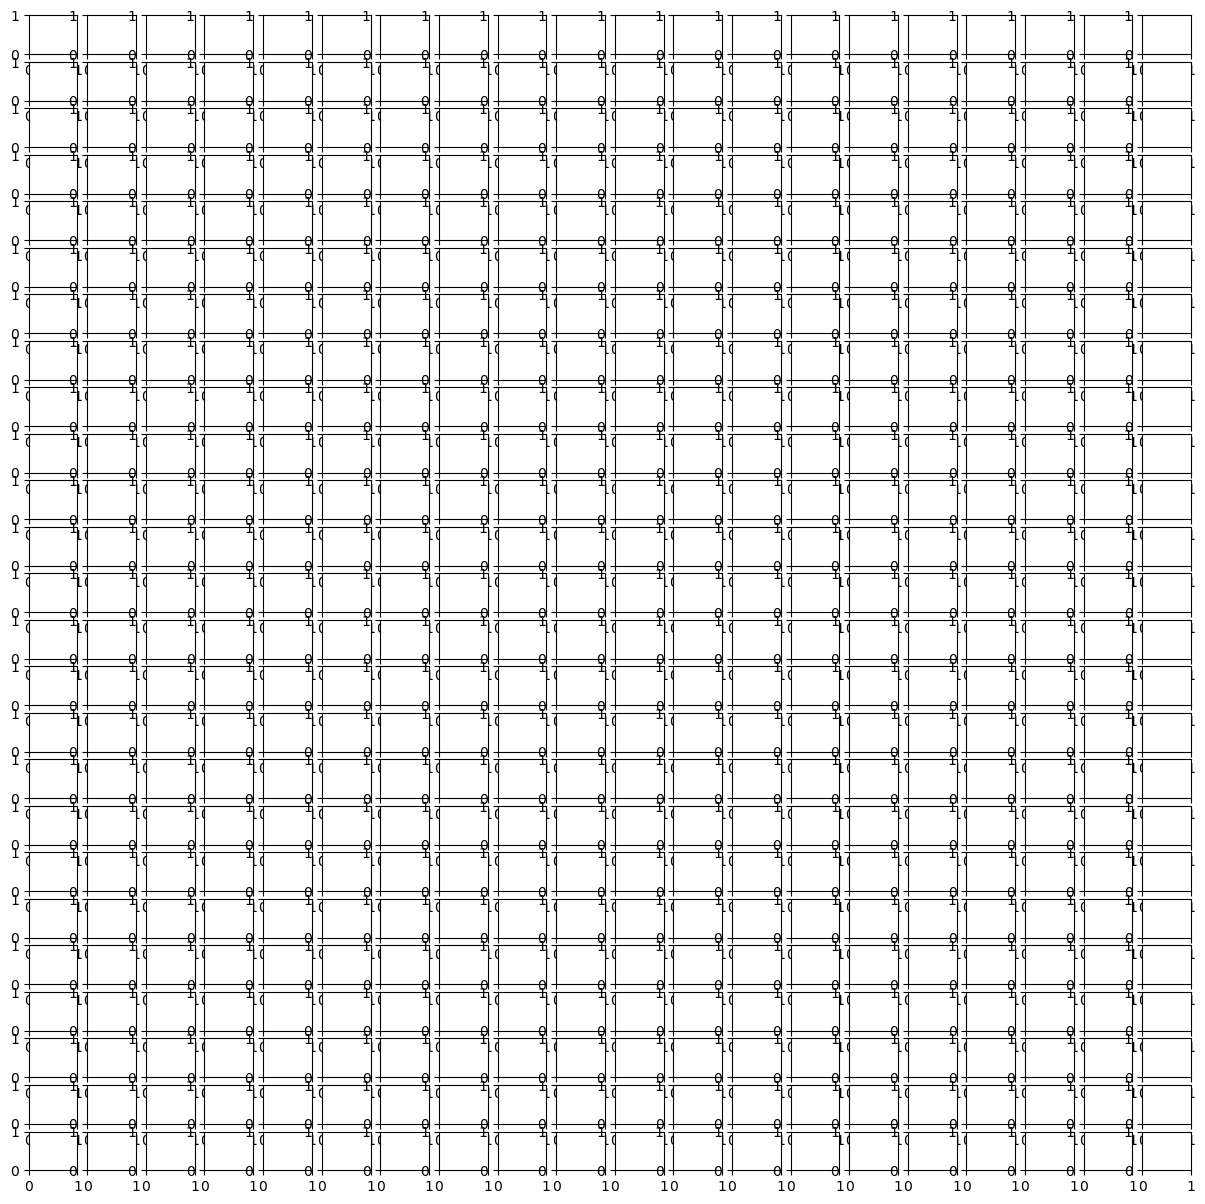

In [11]:
fig, axs = plt.subplots(25, 20, figsize=(15, 15))
axs = axs.flatten()
for i, sample in enumerate(first1000):
    img = sample["image"]
    img.thumbnail((400, 400), Image.Resampling.BOX)
    axs[i].imshow(img)
    axs[i].axis("off")
plt.tight_layout()

In [ ]:
b = stream_ds.batch(1000)
b

IterableDataset({
    features: ['image', 'artist', 'genre', 'style'],
    num_shards: 72
})

In [ ]:
# stream_ds = stream_ds.shuffle(buffer_size=1_000, seed=42)
# first_100 = list(itertools.islice(stream_ds, 100))
# mini_ds = Dataset.from_list(first_100).cast_column("image", datasets.Image())
# style_features = stream_ds.features["style"]
# style_names = style_features.names
# unique_codes = sorted(set(mini_ds["style"]))
# mapping = {i: style_names[i] for i in unique_codes }
# indexesStyles = {i:mapping[s] for i,s in enumerate(mini_ds["style"])}
# counts = Counter(indexesStyles.values())
# labels = list(counts.keys())
# values = list(counts.values())